In [1]:
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import re
from netwulf import visualize
import requests
from bs4 import BeautifulSoup
import xml.etree.ElementTree as ET
import time
import json
from IPython.display import display, clear_output
import community as community_louvain
import matplotlib.cm as cm # access to colormaps
from collections import Counter

# Projektet skal indeholde
### Fra opgavebeskrivelsen
- An explanation of the central idea behind your project (what is the idea?, why is it interesting? which datasets did you need to explore the idea?, how did you download them)
- An outline on the elements you'll need to get to your goal & the implementation plan.
- A walk-through of your preliminary data-analysis, addressing
- What is the total size of your data? (MB, number of rows, number of variables, etc)
- What is the network you will be analyzing? (number of nodes? number of links?, degree distributions, what are node attributes?, etc.)
- What is the text you will be analyzing?
- How will you tie the two together?

### Vores ideer
- Er der nogle communities?
- Hvem er de mest aktive

# Fetching the data and collecting in one dataframe

In [144]:
path_dict = {"agri": "df_agri.csv", 
"energy": "df_energy.csv", 
"enterprise": "df_enterprise.csv", 
"environmental": "df_environmental.csv", 
"fish": "df_fish.csv", 
"industrial": "df_industrial.csv", 
"info": "df_info.csv", 
"research": "df_research.csv", 
"transport": "df_transport.csv", 
}


# Reading the dataframes
df_agri = pd.read_csv(path_dict["agri"])
df_energy = pd.read_csv(path_dict["energy"])
df_enterprise = pd.read_csv(path_dict["enterprise"])
df_environmental = pd.read_csv(path_dict["environmental"])
df_fish = pd.read_csv(path_dict["fish"])
df_industrial = pd.read_csv(path_dict["industrial"])
df_info = pd.read_csv(path_dict["info"])
df_research = pd.read_csv(path_dict["research"])
df_transport = pd.read_csv(path_dict["transport"])

In [ ]:
#Concat all dataframes into one
df = pd.concat([df_agri, df_energy, df_enterprise, df_environmental, df_fish, df_industrial, df_info,
                df_research, df_transport], ignore_index=True)
                
df

,document_id,title,rapporteurs,shadow_rapporteurs,summary_link
0,2024/0027(COD),Granting equivalence with EU requirements to M...,VRECIONOVÁ Veronika (ECR),"BUDA Daniel (EPP), CÂRCIU Gheorghe (S&D), PENN...",https://oeil.secure.europarl.europa.eu/oeil/en...
1,2023/0448(COD),Protection of animals during transport and rel...,"BUDA Daniel (EPP), METZ Tilly (Greens/EFA)","GIMÉNEZ LARRAZ Borja (EPP), VIND Marianne (S&D...",https://oeil.secure.europarl.europa.eu/oeil/en...
2,2023/0447(COD),Welfare of dogs and cats and their traceability,VRECIONOVÁ Veronika (ECR),"DE MEO Salvatore (EPP), NARDELLA Dario (S&D), ...",https://oeil.secure.europarl.europa.eu/oeil/en...
3,2023/0413(COD),Monitoring framework for resilient European fo...,"SARGIACOMO Eric (S&D), WIESNER Emma (Renew)","KÖHLER Stefan (EPP), BERNHUBER Alexander (EPP)...",https://oeil.secure.europarl.europa.eu/oeil/en...
4,2023/0410(COD),Standing Forest and Forestry Expert Group,"TOVERI Pekka (EPP), WIESNER Emma (Renew)","BERNHUBER Alexander (EPP), TEMIDO Marta (S&D),...",https://oeil.secure.europarl.europa.eu/oeil/en...
...,...,...,...,...,...
680,2020/2115(INI),Connectivity and EU-Asia relations,BÜTIKOFER Reinhard (Greens/EFA),"DELI Andor (EPP), OLEKAS Juozas (S&D), DZHAMBA...",https://oeil.secure.europarl.europa.eu/oeil/en...
681,2019/2205(INI),Implementation report on the road safety aspec...,LUTGEN Benoît (EPP),"UJHELYI István (S&D), GHEORGHE Vlad (Renew), M...",https://oeil.secure.europarl.europa.eu/oeil/en...
682,2019/2193(INI),Technical and operational measures for more ef...,DELLI Karima (Greens/EFA),"ADAMOWICZ Magdalena (EPP), TAX Vera (S&D), NAG...",https://oeil.secure.europarl.europa.eu/oeil/en...
683,2019/2192(INI),Revision of the Trans-European Transport Netwo...,GIESEKE Jens (EPP),"GARCÍA MUÑOZ Isabel (S&D), RIQUET Dominique (R...",https://oeil.secure.europarl.europa.eu/oeil/en...


In [146]:
#Keep track of what the topics are
df_agri['topic'] = 'agri'
df_energy['topic'] = 'energy'
df_enterprise['topic'] = 'enterprise'
df_environmental['topic'] = 'environmental'
df_fish['topic'] = 'fish'
df_industrial['topic'] = 'industrial'
df_info['topic'] = 'info'
df_research['topic'] = 'research'
df_transport['topic'] = 'transport'

df_topic = pd.concat([df_agri, df_energy, df_enterprise, df_environmental, df_fish, df_industrial, df_info,
                df_research, df_transport], ignore_index=True)
df_topic

df_dict = {"collected":df_topic,
"agri":df_agri,
"energy":df_energy,
"enterprise":df_enterprise,
"environmental":df_environmental,
"fish":df_fish,
"industrial":df_industrial,
"info":df_info,
"research":df_research,
"transport":df_transport
}

# Light-Preprocessing

## Extract missing Summary links:

OPIONAL: Do not run this if the project is complete.

In [135]:
def get_summary_link(procedure_id, retries=3, delay=2, headers=None, max_timeout=None):
    root = "https://oeil.secure.europarl.europa.eu/oeil/sl/procedure-file?reference="
    id = procedure_id # Takes from the input parameters , Example: "2022/0424(COD)"
    link = root + id # Forms Proceeding Ulr-Link

    print("Procedure:", link) 
    r = fetch_with_retry(link, retries, delay, headers, max_timeout) # Requests Procedure URL
    soup = BeautifulSoup(r.content)
    status = soup.find("p", string="Status").find_next_sibling("p").get_text(strip=True)

    print("Procedure Status: " + status)

    rows = soup.find_all('tr')

    summary_dict = {}

    for row in rows:
        button = row.find('button', string='Summary')
        if button:
            try:
                # Get the link from the parent <a>
                summary_link = button.find_parent('a')['href']
                full_link = "https://oeil.secure.europarl.europa.eu" + summary_link

                # Get event label from second <td> in the row
                tds = row.find_all('td')
                event_label = tds[1].get_text(strip=True) if len(tds) > 1 else "Unknown"

                summary_dict[event_label] = full_link

            except Exception as e:
                print(f"Error processing row: {e}")

    print(summary_dict)
    if not summary_dict:
        print("No Summaries Found, Please Fetch or Manually extract from Supplementing Procedure.")
    return summary_dict # Returns a dictionary of summary links with event labels as keys.

def update_csv_element(csv_path, document_id, target_column, new_value):

    df = pd.read_csv(csv_path)

    # Check that the column and ID exist
    if 'document_id' not in df.columns:
        raise ValueError("'document_id' column not found in the CSV.")
    if target_column not in df.columns:
        raise ValueError(f"'{target_column}' column not found in the CSV.")

    # Check if the document_id exists
    mask = df['document_id'] == document_id
    if not mask.any():
        raise ValueError(f"document_id '{document_id}' not found in the CSV.")

    # Update the value
    df.loc[mask, target_column] = new_value

    # Save the updated CSV
    df.to_csv(csv_path, index=False)
    print(f"Updated '{target_column}' for document_id '{document_id}', in {csv_path}.")

def get_nan(df, column, id_col): # Get a list of all IDs that contain a NAN element in a specified column
    nan_rows = df[df[column].isna()]
    return nan_rows[id_col].tolist()



In [ ]:
### Update Loop
### Re-Run dataframes again above

for key in path_dict.keys():
    key_df = df_dict[key]
    key_path = path_dict[key]

    nan_list = get_nan(key_df, "summary_link", "document_id")

    for nan_id in nan_list:
        nan_summary_dict = get_summary_link(nan_id)

        if not nan_summary_dict:
            print("Skipping: No dict")
            continue
        else:
            first_key = next(iter(nan_summary_dict))
            s_link = nan_summary_dict[first_key]
            clear_output()
            update_csv_element(key_path, nan_id, "summary_link", s_link)

In [147]:
# Check total Nans
len(get_nan(df_dict["collected"], "summary_link", "document_id"))

30

## Voting

In [148]:
votedict = {0: "For", 1: "Against", 2: "Abstained"} 

def fetch_with_retry(url, retries=3, delay=2, headers=None, max_timeout=None):
    if headers is None:
        # headers = {'User-Agent': 'Mozilla/5.0'}
        headers = None
    
    for attempt in range(retries):
        try:
            response = requests.get(url, headers=headers, timeout=max_timeout)
            if response.status_code == 200:
                return response
            elif response.status_code in [500, 502, 503, 504, 408]:
                print(f"Server error ({response.status_code}), retrying ({attempt + 1}/{retries})...")
            elif response.status_code == 404:
                print("Page not found (404), not retrying.")
                return None
            else:
                print(f"Unexpected status code: {response.status_code}")
                return None
        except requests.exceptions.RequestException as e:
            print(f"Request failed: {e}, retrying ({attempt + 1}/{retries})...")
        time.sleep(delay)
    return None

def check_voting(proceedure_id: str, politicians: list, retries=3, delay=2, headers=None, max_timeout=None):
    root = 'https://oeil.secure.europarl.europa.eu/oeil/sl/procedure-file?reference='
    id = proceedure_id # Takes from the input parameters , Example: "2022/0424(COD)"
    link = root + id # Forms Proceeding Ulr-Link

    names = politicians
    info_dict = {name: {} for name in names}

    print("Procedure:", link) 
    r = fetch_with_retry(link, retries, delay, headers, max_timeout) # Requests Procedure URL
    soup = BeautifulSoup(r.content)
    status = soup.find("p", string="Status").find_next_sibling("p").get_text(strip=True)

    print("Procedure Status: " + status)

    voting = soup.find('a', title="Results of vote in Parliament") # Finds section with link to votes result
    if voting:
        print("Votes Found")    
        voting_link = voting['href'] # Extracts the URL
        item = voting_link.split('item=')[-1] # Saves the Item Number (The VR page contains multiple results, clicking the physical link only expands the specific results table. This is needed to find the specific proceeding on the page)
        print("VOT Link found:", voting_link) 

        rv = fetch_with_retry(voting_link, retries, delay, headers, max_timeout) # Requests the voting results URL (results, voting)
        soupv = BeautifulSoup(rv.content)

        table = soupv.find('table', id='ITM-'+str(item)) # Seaches for the designated table containing the specific procedure
        # print(table.find_all("a")) # Prints the table row
        if table == None:
            rcv_link_tag = None
        else:
            rcv_link_tag = table.find('a', href=lambda href: href and 'RCV_EN.html' in href) # Extracts the RCV page in the table

        if rcv_link_tag:
            rcv_href = rcv_link_tag['href']
            rcv_url = "https://www.europarl.europa.eu"+rcv_href # This URL leads to the specific voting data of the politicians
            print("RCV Vote Link found:", rcv_url) 

            tableid = rcv_url.split('#')[-1] # Saves the Item Number (Same issue at RCV page as for voting page)
            rr = fetch_with_retry(rcv_url, retries, delay, headers, max_timeout) # Requests the RCV page (results, rcv)
            soupr = BeautifulSoup(rr.content)

            table_v = soupr.find('table', id='table'+str(tableid)) # Finds the designated proceeding by the table ID

            if table_v:
                print("Found the table with RCV ID!")

                content_id = rcv_url.split('#')[1] # Easier to find table containing names, since it's marked by an ID in the RCV URL
                contents = table_v.find(id="div"+str(content_id)) # Search for section

                tables = contents.find_all('table') # Find subtable, containing names

                ### The section should contain 3 tables with names indicating a vote. Table index ordering is: For, Against, Abstained 
                ### Searches for the name in each Vote table
                for name in names:
                    for i in range(3):
                        if name.lower() in tables[i].get_text().lower():
                            print(f"{name} is {votedict[i]}")
                            info_dict[name] = i

                clear_output() # CLEARNING OUTPUT
                info_dict = {k: (2 if v == {} else v) for k, v in info_dict.items()} # Filling non present votes with abstained
                return info_dict
                
            else:
                print("Table with the RCV ID not found.")
            

        else:
            print("RCV vote link not found.")
    else:
        print("No Votes available")

def extract_surname(name):
    words = name.split()
    surname_parts = []

    for i in range(len(words)):
        word = words[i]

        # If the word is all uppercase, it's part of the surname
        if word.isupper():
            surname_parts.append(word)
        else:
            # Once we hit a word that's not all caps, we assume it's the start of the first name
            break

    return " ".join(surname_parts)

def save_votes(proc_id_, dict_, filename="voting_results.json"):
    try:
        with open(filename, "r", encoding="utf-8") as f:
            data = json.load(f)
    except FileNotFoundError:
        data = {}

    data[proc_id_] = dict_  # Add or update the procedure's votes

    with open(filename, "w", encoding="utf-8") as f:
        json.dump(data, f, indent=2, ensure_ascii=False)
        print("Votes Saved.")


### OPTIONAL: to gather vote data for available procedures

In [9]:
# DF Configurations
target_df = df_topic 
votedata_file = "votedata.json"

try:
    with open(votedata_file, "r", encoding="utf-8") as f:
        current_vote_data = json.load(f)
except FileNotFoundError:
    current_vote_data = {}

for i in range(len(target_df)):
    t_id = target_df.iloc[i]["document_id"]

    if t_id in current_vote_data:
        print("Skipping:",t_id)
        continue

    t_names = [] if pd.isna(target_df.iloc[i]["shadow_rapporteurs"]) else target_df.iloc[i]["shadow_rapporteurs"].split(",")
    [t_names.append(n) for n in target_df.iloc[i]["rapporteurs"].split(",")]

    t_names = [extract_surname(n) for n in t_names]
    result_dict = check_voting(t_id, t_names, retries=50, delay=2, headers=None, max_timeout=20) # Params
    print(result_dict)
    # if result_dict == None:
        # continue
    
    save_votes(t_id, result_dict, votedata_file)

clear_output()

# Network Investigation

To investigate how and who works together a network analysis will be performed, and a network should be created. To start a simple network is made using a weighting of a link using the number of times a person is mentioned in a procedure with another person. This is done by using the columns "rapporteur" and "shadow-rapporteur", where names are split in the column "shadow-rapporteur", since one entry can contain multiple names, and is finally collected in a network using the nx.Graph package.

In [149]:
# Helper function to clean and split names
def split_names(name_str):
    if pd.isna(name_str):
        return []
    return [name.strip() for name in name_str.split(",")]

# Create a network graph for a chosen graph
def create_network(dataframe):
    G = nx.Graph()
    
    for _, row in dataframe.iterrows():
        rapporteurs = split_names(row["rapporteurs"])
        shadow_rapporteurs = split_names(row["shadow_rapporteurs"])
        participants = rapporteurs + shadow_rapporteurs

        for person in participants:
            if not G.has_node(person):
                G.add_node(person)

        for i, p1 in enumerate(participants):
            for p2 in participants[i+1:]:
                if G.has_edge(p1, p2):
                    G[p1][p2]['weight'] += 1
                else:
                    G.add_edge(p1, p2, weight=1)

    # Assign 'Party' attribute to each node
    for person in G.nodes:
        if '(' in person and ')' in person:
            party = person[person.find('('):].strip()  # includes parentheses
        else:
            party = None
        G.nodes[person]["Party"] = party

    return G

G_collected =create_network(df)
G_agri = create_network(df_agri)
G_energy = create_network(df_energy)
G_enterprise = create_network(df_enterprise)
G_environmental = create_network(df_environmental)
G_fish = create_network(df_fish)
G_industrial = create_network(df_industrial)
G_info = create_network(df_info)
G_research = create_network(df_research)
G_transport = create_network(df_transport)

network_dict = {"collected":G_collected,
"agri":G_agri,
"energy":G_energy,
"enterprise":G_enterprise,
"environmental":G_environmental,
"fish":G_fish,
"industrial":G_industrial,
"info":G_info,
"research":G_research,
"transport":G_transport
}

It seems that the network has a very high degree of connectivity, and making meaningful insights from the network might be difficult. To adress this a thresholding is applied based on the number of times a person is mentioned in a procedure with another person. The threshold is determined by examining the distribution of links between people in the network.

In [150]:
def number_links(Graph):
    degree_dict = dict(Graph.degree())
    degree_df = pd.DataFrame(degree_dict.items(), columns=["Person", "Num_Links"])
    degree_df_sorted = degree_df.sort_values(by="Num_Links", ascending=False)
    return degree_df_sorted

degree_col = number_links(G_collected)
degree_info = number_links(G_info)
degree_agri = number_links(G_agri)
degree_energy = number_links(G_energy)
degree_ent = number_links(G_enterprise)
degree_env = number_links(G_environmental)
degree_fish = number_links(G_fish)
degree_ind = number_links(G_industrial)
degree_res = number_links(G_research)
degree_transport = number_links(G_transport)

In [151]:
degree_fish['Num_Links'].describe()

count    97.000000
mean     13.092784
std       9.326354
min       0.000000
25%       6.000000
50%      11.000000
75%      18.000000
max      44.000000
Name: Num_Links, dtype: float64

In [152]:
percentiles = [0.1, 0.25, 0.5, 0.75, 0.9, 0.95, 0.99]
degree_col['Num_Links'].quantile(percentiles)

0.10     5.0
0.25     7.0
0.50    15.0
0.75    27.0
0.90    43.0
0.95    56.0
0.99    81.0
Name: Num_Links, dtype: float64

### Degree Insights (Links)

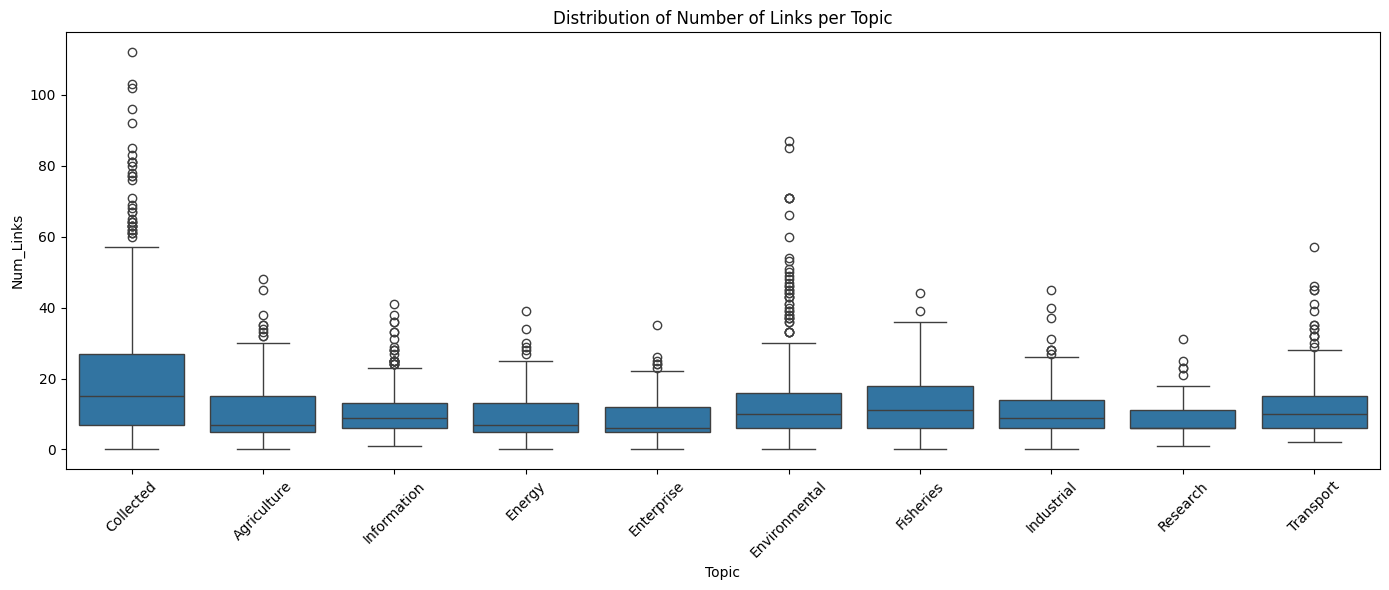

In [153]:
import seaborn as sns
df_all = pd.concat([
    degree_col[['Num_Links']].assign(Topic='Collected'),
    degree_agri[['Num_Links']].assign(Topic='Agriculture'),
    degree_info[['Num_Links']].assign(Topic='Information'),
    degree_energy[['Num_Links']].assign(Topic='Energy'),
    degree_ent[['Num_Links']].assign(Topic='Enterprise'),
    degree_env[['Num_Links']].assign(Topic='Environmental'),
    degree_fish[['Num_Links']].assign(Topic='Fisheries'),
    degree_ind[['Num_Links']].assign(Topic='Industrial'),
    degree_res[['Num_Links']].assign(Topic='Research'),
    degree_transport[['Num_Links']].assign(Topic='Transport')
])

plt.figure(figsize=(14, 6))
sns.boxplot(data=df_all, x='Topic', y='Num_Links')
plt.xticks(rotation=45)
plt.title('Distribution of Number of Links per Topic')
plt.tight_layout()
plt.show()

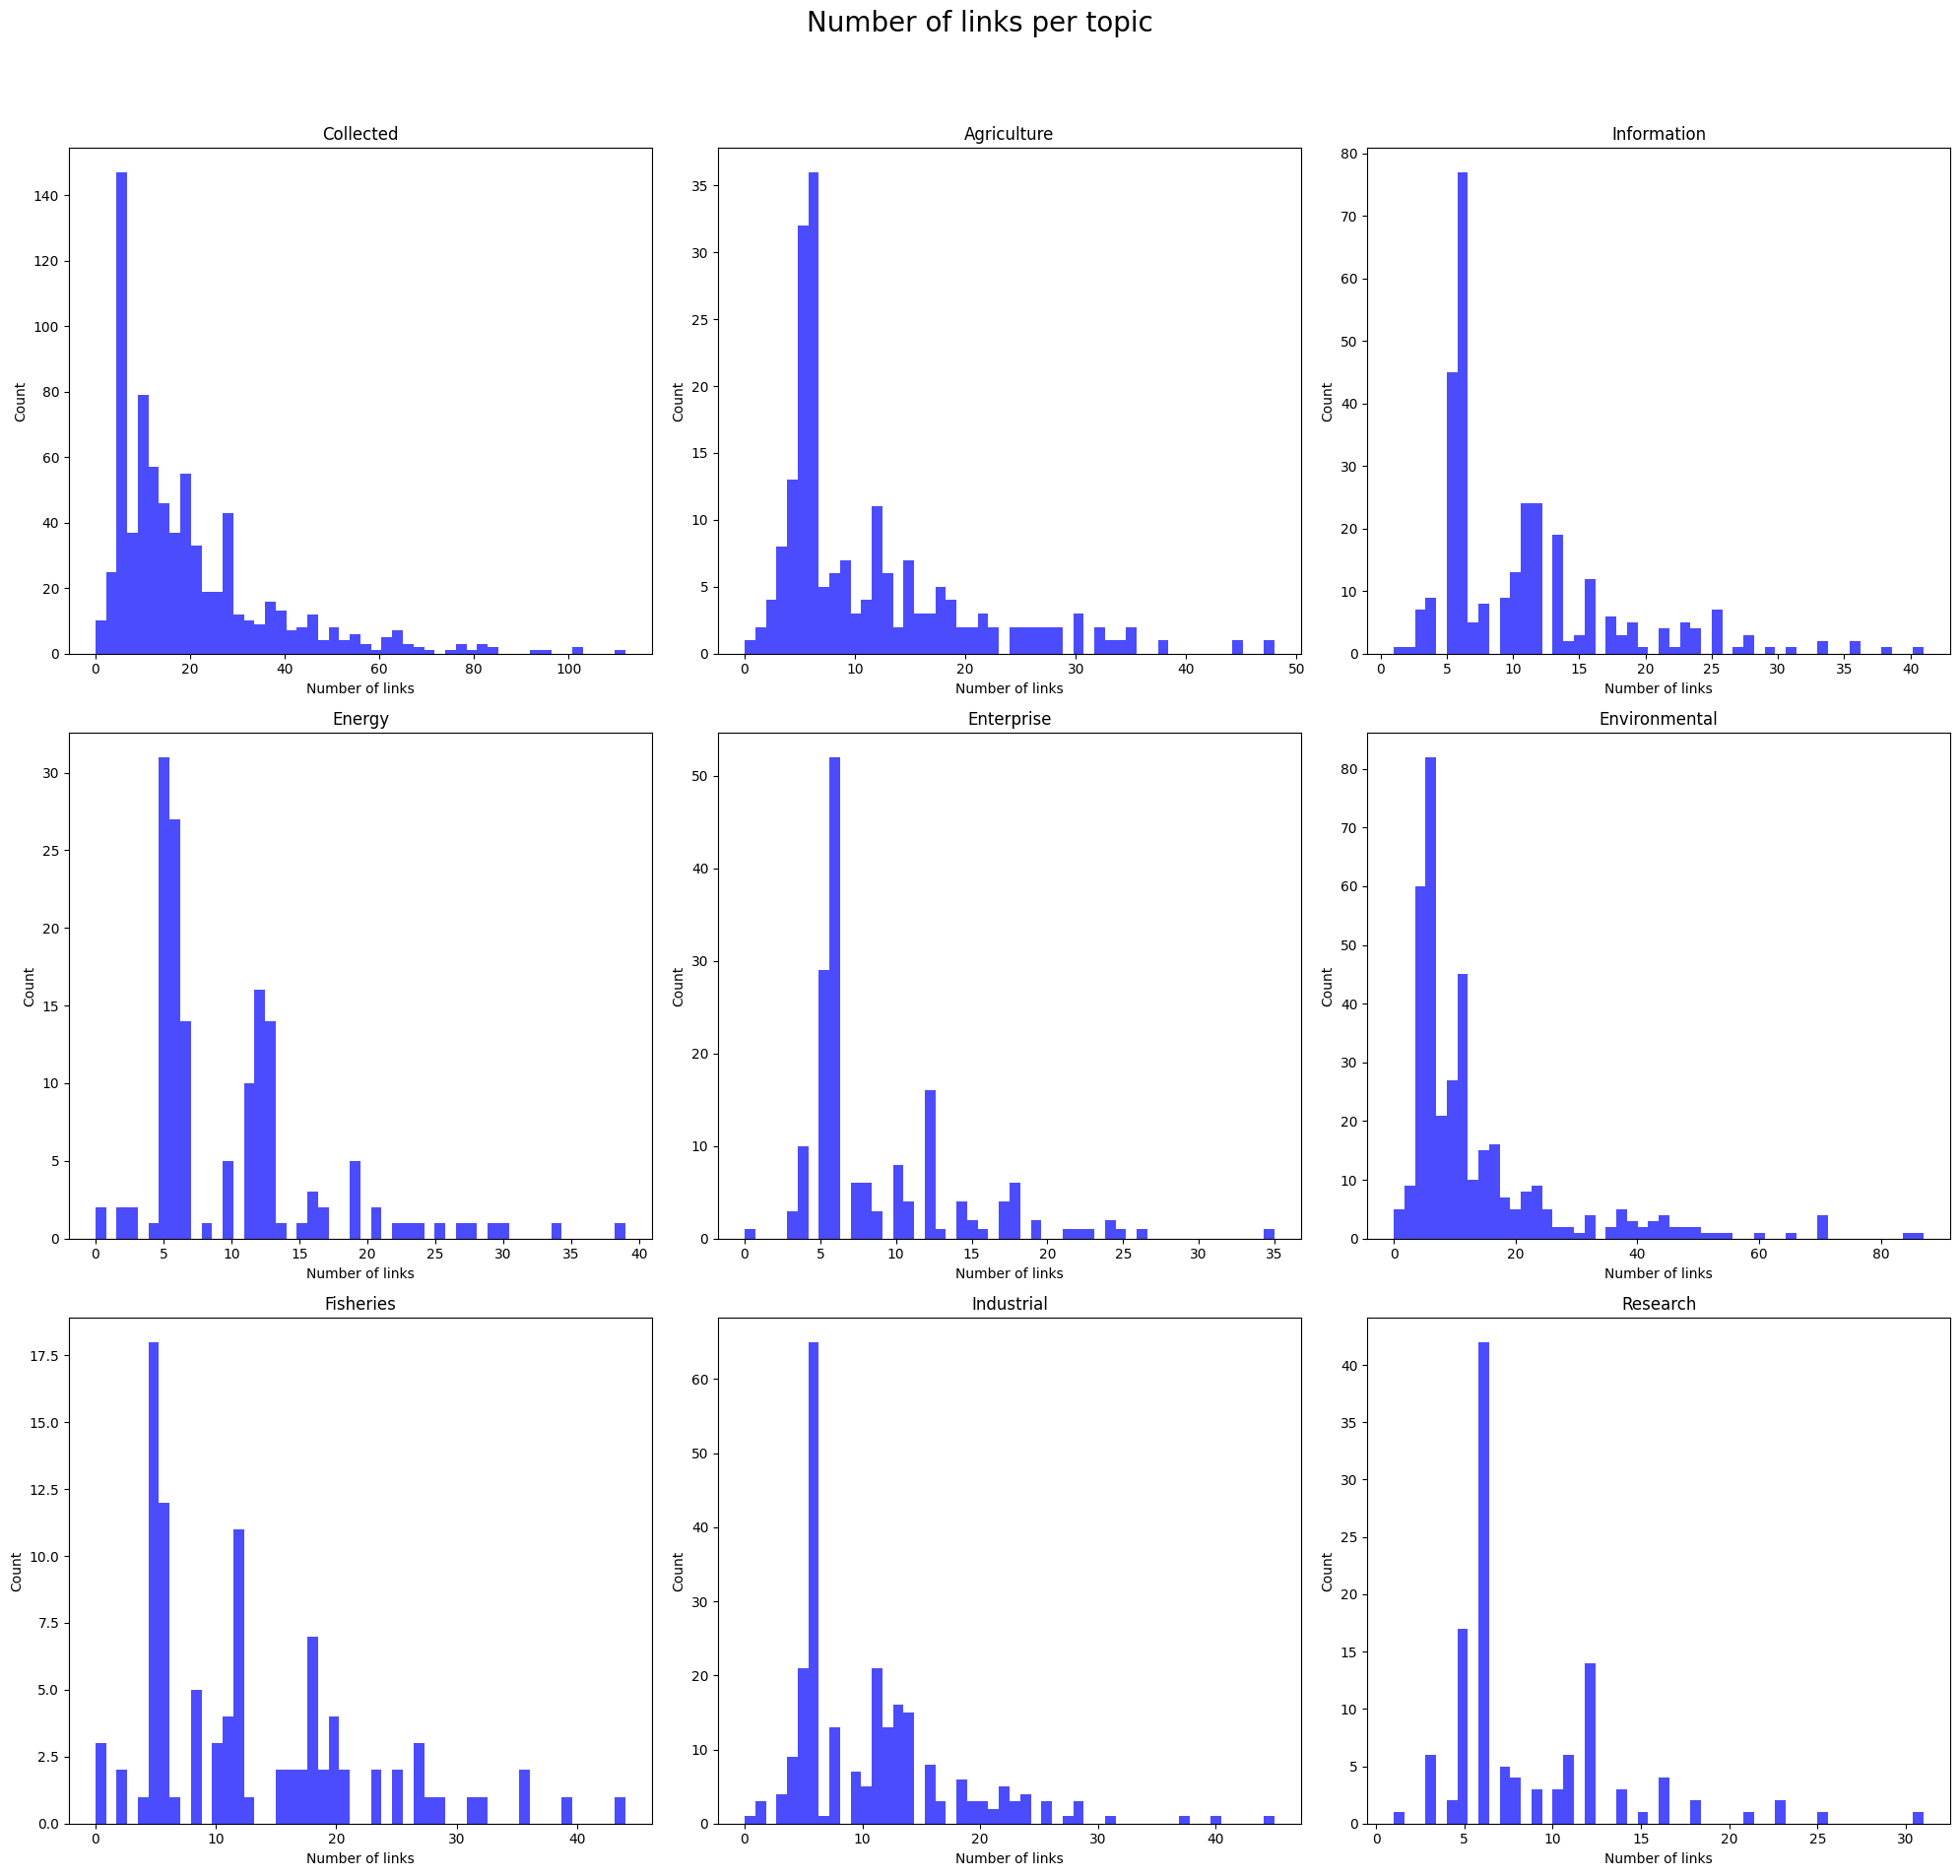

In [154]:
topics = [
    ('Collected', degree_col),
    ('Agriculture', degree_agri),
    ('Information', degree_info),
    ('Energy', degree_energy),
    ('Enterprise', degree_ent),
    ('Environmental', degree_env),
    ('Fisheries', degree_fish),
    ('Industrial', degree_ind),
    ('Research', degree_res),
]

# Create subplots
fig, axs = plt.subplots(3, 3, figsize=(20, 20))
fig.suptitle('Number of links per topic', fontsize=20)

# Plot each histogram
for ax, (title, df) in zip(axs.flat, topics):
    ax.hist(df['Num_Links'], bins=50, color='blue', alpha=0.7)
    ax.set_title(title)
    ax.set_xlabel('Number of links')
    ax.set_ylabel('Count')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

As can be seen from the plots above, most of of the links are in the range 0-15%, so using a small threshold will decrease the number of links significantly.

In [155]:
def threshold_weight(Graph, threshold):
    Graph_filtered = nx.Graph()

    for u, v, data in Graph.edges(data=True):
        if data['weight'] >= threshold:
            Graph_filtered.add_edge(u, v, weight=data['weight'])

    for node in Graph.nodes:
            if node in Graph_filtered:
                Graph_filtered.nodes[node].update(Graph.nodes[node])  # copy node attributes
            elif node not in Graph_filtered:
                Graph_filtered.add_node(node)  # to include even disconnected nodes

    return Graph_filtered

def remove_disconnected_nodes(Graph):
    Graph_cleaned = Graph.copy()
    for node in list(Graph_cleaned.nodes):
        if Graph_cleaned.degree(node) == 0:
            Graph_cleaned.remove_node(node)
    return Graph_cleaned


G_col_fil = threshold_weight(G_collected, 3)
G_agri_fil = threshold_weight(G_agri,2)
G_energy_fil = threshold_weight(G_energy,2)
G_enterprise_fil = threshold_weight(G_enterprise,2)
G_environmental_fil = threshold_weight(G_environmental,2)
G_fish_fil = threshold_weight(G_fish,2)
G_industrial_fil = threshold_weight(G_industrial,2)
G_info_fil = threshold_weight(G_info,2)
G_research_fil = threshold_weight(G_research,2)
G_transport_fil = threshold_weight(G_transport, 2)


filtered_network_dict = {"collected":remove_disconnected_nodes(G_col_fil),
    "agri":remove_disconnected_nodes(G_agri_fil),
    "energy":remove_disconnected_nodes(G_energy_fil),
    "enterprise":remove_disconnected_nodes(G_enterprise_fil),
    "environmental":remove_disconnected_nodes(G_environmental_fil),
    "fish":remove_disconnected_nodes(G_fish_fil),
    "industrial":remove_disconnected_nodes(G_industrial_fil),
    "info":remove_disconnected_nodes(G_info_fil),
    "research":remove_disconnected_nodes(G_research_fil),
    "transport":remove_disconnected_nodes(G_transport_fil)
}


# Plotting the networks

In [156]:
def plot_network(Graph):
    plt.figure(figsize=(12, 12))
    pos = nx.spring_layout(Graph, k=0.15)
    weights = [Graph[u][v]['weight'] for u,v in Graph.edges()]
    nx.draw_networkx_nodes(Graph, pos, node_size=50)
    nx.draw_networkx_edges(Graph, pos, width=weights, alpha=0.5)
    plt.title("Rapporteur / Shadow Rapporteur Network")
    plt.axis('off')
    plt.show()

In [157]:
def plot_network_netwulf(Graph):
    visualize(Graph)
    plt.show()

plot_network_netwulf(G_fish_fil)

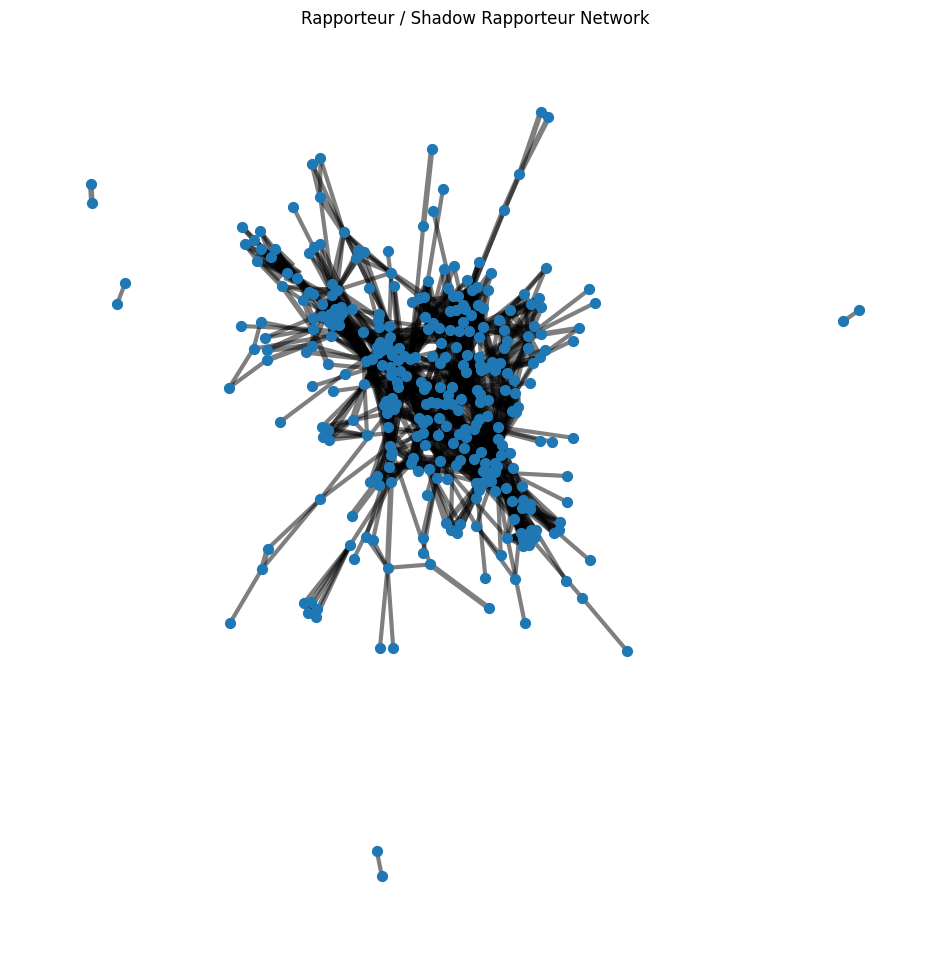

In [158]:
plot_network(filtered_network_dict["collected"])

## Trying to color based on political party

In [27]:
def split_people(cell):
    if pd.isna(cell):
        return []
    return [p.strip() for p in cell.split(",")]

def get_party(person):
    match = re.search(r"\((.*?)\)", person)
    return match.group(1) if match else "NI"

dfs = [df_topic, df_info, df_agri, df_energy, df_enterprise, df_environmental, df_fish, df_industrial, df_research, df_transport]

for df in dfs:
    df['rapporteur_list'] = df['rapporteurs'].apply(split_people)
    df['shadow_list'] = df['shadow_rapporteurs'].apply(split_people)




In [28]:
all_people = set([person for sublist in df_topic['rapporteur_list'].tolist() + df_topic['shadow_list'].tolist() for person in sublist])
party_lookup = {person: get_party(person) for person in all_people}
parties = set(party_lookup.values())
parties

{'ALDE',
 'ECR',
 'EFDD',
 'EPP',
 'ESN',
 'GUE/NGL',
 'Greens/EFA',
 'ID',
 'NI',
 'PPE',
 'PfE',
 'Renew',
 'S&D',
 'The Left',
 'Verts/ALE'}

In [29]:
party_colors = {
    "EPP": "#1f77b4",
    "S&D": "#d62728",
    "Renew": "#ff7f0e",
    "Greens/EFA": "#2ca02c",
    "ECR": "#9467bd",
    "ID": "#8c564b",
    "The Left": "#e377c2",
    "NI": "#7f7f7f"
}

In [30]:
def create_network_parties(df, min_weight):
    Graph = nx.Graph()
    for _, row in df.iterrows():
        rapporteurs = row['rapporteur_list']
        shadows = row['shadow_list']
        
        participants = rapporteurs + shadows
        for person in participants:
            if not Graph.has_node(person):
                Graph.add_node(person, party=party_lookup.get(person, "Unknown"))
        
        for i in range(len(participants)):
            for j in range(i + 1, len(participants)):
                p1, p2 = participants[i], participants[j]
                if Graph.has_edge(p1, p2):
                    Graph[p1][p2]['weight'] += 1
                else:
                    Graph.add_edge(p1, p2, weight=1)
    edges_to_remove = [(u, v) for u, v, d in Graph.edges(data=True) if d['weight'] < min_weight]
    Graph.remove_edges_from(edges_to_remove)

    return Graph
G_parties = create_network_parties(df_topic, 3)
G_parties_info = create_network_parties(df_info, 2)
G_parties_agri = create_network_parties(df_agri, 2)
G_parties_energy = create_network_parties(df_energy, 2)
G_parties_enterprise = create_network_parties(df_enterprise, 2)
G_parties_environmental = create_network_parties(df_environmental, 2)
G_parties_fish = create_network_parties(df_fish, 2)
G_parties_industrial = create_network_parties(df_industrial, 2)
G_parties_research = create_network_parties(df_research, 2)
G_parties_transport = create_network_parties(df_transport, 2)


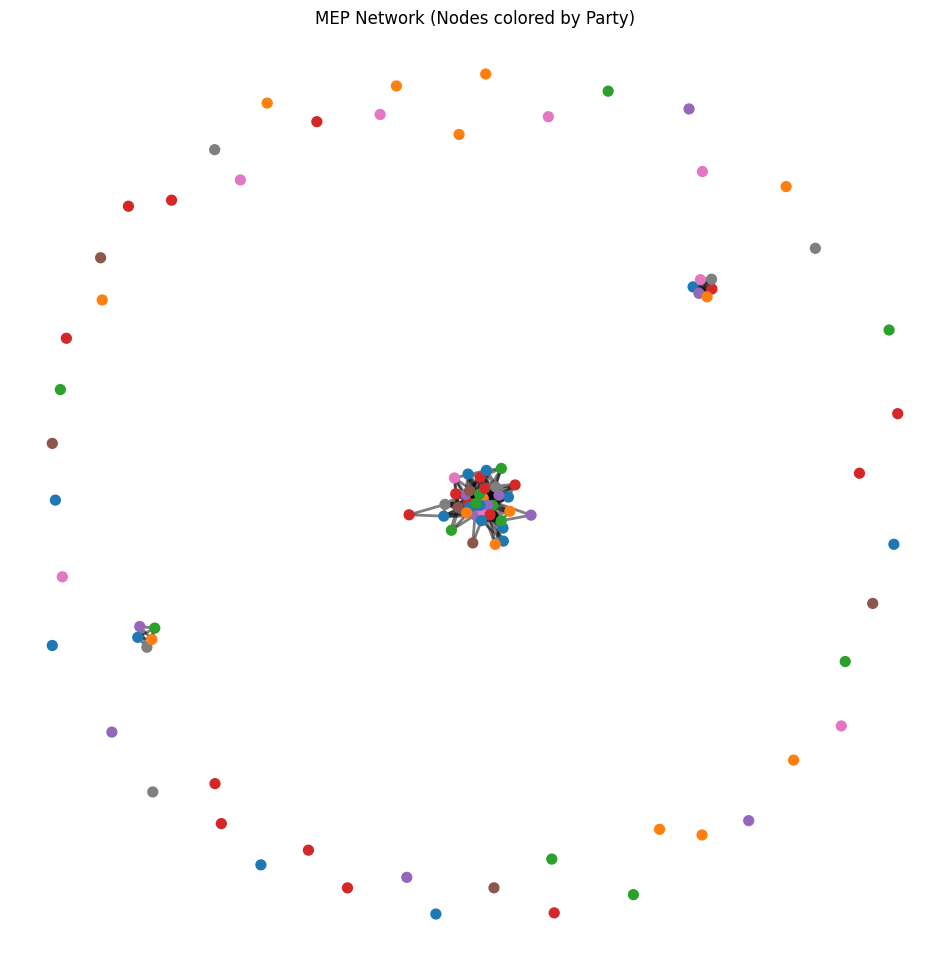

In [31]:
def plot_network_parties(Graph):
    node_colors = [party_colors.get(Graph.nodes[n]['party'], "#7f7f7f") for n in Graph.nodes]

    plt.figure(figsize=(12, 12))
    pos = nx.spring_layout(Graph, k=0.15)
    nx.draw_networkx_nodes(Graph, pos, node_color=node_colors, node_size=50)
    nx.draw_networkx_edges(Graph, pos, width=[Graph[u][v]['weight'] for u,v in Graph.edges()], alpha=0.5)
    plt.title("MEP Network (Nodes colored by Party)")
    plt.axis("off")
    plt.show()

plot_network_parties(G_parties_fish)

In [32]:
def plot_network_parties_netwulf(Graph):
    for node in Graph.nodes:
        if Graph.degree(node) == 0:
            Graph.nodes[node]['size'] = 1 
            Graph.nodes[node]['color'] = party_colors.get(party, "#cccccc")
        else:
            party = get_party(node)
            Graph.nodes[node]['size'] = Graph.degree(node)
            Graph.nodes[node]['color'] = party_colors.get(party, "#cccccc")

    visualize(Graph)
    plt.show()
    

plot_network_parties_netwulf(G_parties)

## Coloring based on topic

In [34]:
topic_colors = {
    "agri": "#1f77b4", #blue
    "energy": "#d62728", #red
    "enterprise": "#ff7f0e", #orange
    "environmental": "#2ca02c", #green
    "fish": "#9467bd", #purple
    "industrial": "#8c564b", #brown
    "info": "#e377c2", #pink
    "research": "#17becf", #muted cyan
    "transport": "#bcbd22" #olive yellow
}

In [35]:
from collections import defaultdict, Counter
def split_people(cell):
    if pd.isna(cell):
        return []
    return [p.strip() for p in cell.split(",")]

def get_party(person):
    match = re.search(r"\((.*?)\)", person)
    return match.group(1) if match else "NI"

df_topic['rapporteur_list'] = df_topic['rapporteurs'].apply(split_people)
df_topic['shadow_list'] = df_topic['shadow_rapporteurs'].apply(split_people)

person_topics = defaultdict(list)

for _, row in df_topic.iterrows():
    topic = row['topic']
    people = row['rapporteur_list'] + row['shadow_list']
    for person in people:
        person_topics[person].append(topic)

# Step 2: Assign most common topic to each person
person_topic = {
    person: Counter(topics).most_common(1)[0][0]
    for person, topics in person_topics.items()
}

In [36]:
def plot_network_topics_netwulf(Graph):
    for node in Graph.nodes():
        topic = person_topic.get(node, "unknown")
        color = topic_colors.get(topic, "#cccccc")  # default gray if not in dict
        Graph.nodes[node]['color'] = color
        
    visualize(Graph)
    plt.show()

plot_network_topics_netwulf(G_parties_research)

# Basic inspection

- What is the total size of your data? (MB, number of rows, number of variables, etc)

In [37]:
#Dataset size
print(f"df_topic has {df_topic.shape[0]} rows and {df_topic.shape[1]} columns. The size is {df_topic.memory_usage(index=True).sum() / 1024 * 1024:.2f} bytes.")
print(f"Dataframe looks like:")
df_topic.head()

df_topic has 685 rows and 8 columns. The size is 43968.00 bytes.
Dataframe looks like:


,document_id,title,rapporteurs,shadow_rapporteurs,summary_link,topic,rapporteur_list,shadow_list
0,2024/0027(COD),Granting equivalence with EU requirements to M...,VRECIONOVÁ Veronika (ECR),"BUDA Daniel (EPP), CÂRCIU Gheorghe (S&D), PENN...",https://oeil.secure.europarl.europa.eu/oeil/en...,agri,[VRECIONOVÁ Veronika (ECR)],"[BUDA Daniel (EPP), CÂRCIU Gheorghe (S&D), PEN..."
1,2023/0448(COD),Protection of animals during transport and rel...,"BUDA Daniel (EPP), METZ Tilly (Greens/EFA)","GIMÉNEZ LARRAZ Borja (EPP), VIND Marianne (S&D...",https://oeil.secure.europarl.europa.eu/oeil/en...,agri,"[BUDA Daniel (EPP), METZ Tilly (Greens/EFA)]","[GIMÉNEZ LARRAZ Borja (EPP), VIND Marianne (S&..."
2,2023/0447(COD),Welfare of dogs and cats and their traceability,VRECIONOVÁ Veronika (ECR),"DE MEO Salvatore (EPP), NARDELLA Dario (S&D), ...",https://oeil.secure.europarl.europa.eu/oeil/en...,agri,[VRECIONOVÁ Veronika (ECR)],"[DE MEO Salvatore (EPP), NARDELLA Dario (S&D),..."
3,2023/0413(COD),Monitoring framework for resilient European fo...,"SARGIACOMO Eric (S&D), WIESNER Emma (Renew)","KÖHLER Stefan (EPP), BERNHUBER Alexander (EPP)...",https://oeil.secure.europarl.europa.eu/oeil/en...,agri,"[SARGIACOMO Eric (S&D), WIESNER Emma (Renew)]","[KÖHLER Stefan (EPP), BERNHUBER Alexander (EPP..."
4,2023/0410(COD),Standing Forest and Forestry Expert Group,"TOVERI Pekka (EPP), WIESNER Emma (Renew)","BERNHUBER Alexander (EPP), TEMIDO Marta (S&D),...",https://oeil.secure.europarl.europa.eu/oeil/en...,agri,"[TOVERI Pekka (EPP), WIESNER Emma (Renew)]","[BERNHUBER Alexander (EPP), TEMIDO Marta (S&D)..."


In [38]:
print(f"df_agri has {df_agri.shape[0]} rows and {df_agri.shape[1]} columns. The size is {df_agri.memory_usage(index=True).sum() / 1024 * 1024:.2f} bytes.")
print(f"df_energy has {df_energy.shape[0]} rows and {df_energy.shape[1]} columns. The size is {df_energy.memory_usage(index=True).sum() / 1024 * 1024:.2f} bytes.")

df_agri has 88 rows and 8 columns. The size is 5760.00 bytes.
df_energy has 36 rows and 8 columns. The size is 2432.00 bytes.


- What is the network you will be analyzing? (number of nodes? number of links?, degree distributions, what are node attributes?, etc.)

In [39]:
#Number of nodes
print(f"Whole network: {len(G_collected.nodes())}\nAgriculture: {len(G_agri.nodes())}\nEnergy: {len(G_energy.nodes())}\nEnterprise: {len(G_enterprise.nodes())}\nEnvironmental: {len(G_environmental.nodes())}\nFish: {len(G_fish.nodes())}\nIndustrial: {len(G_industrial.nodes())}\nInfo: {len(G_info.nodes())}\nResearch: {len(G_research.nodes())}\nTransport: {len(G_transport.nodes())}")

Whole network: 753
Agriculture: 193
Energy: 149
Enterprise: 166
Environmental: 369
Fish: 97
Industrial: 242
Info: 307
Research: 118
Transport: 227


In [40]:
networks = {
    "Whole network": (G_collected, G_col_fil),
    "Agriculture": (G_agri, G_agri_fil),
    "Energy": (G_energy, G_energy_fil),
    "Enterprise": (G_enterprise, G_enterprise_fil),
    "Environmental": (G_environmental, G_environmental_fil),
    "Fish": (G_fish, G_fish_fil),
    "Industrial": (G_industrial, G_industrial_fil),
    "Info": (G_info, G_info_fil),
    "Research": (G_research, G_research_fil),
    "Transport": (G_transport, G_transport_fil),
}

print(f"{'Topic':<15} {'Before':>10} {'After':>10}")
print("-" * 37)

for name, (G_before, G_after) in networks.items():
    print(f"{name:<15} {len(G_before.edges()):>10} {len(G_after.edges()):>10}")


Topic               Before      After
-------------------------------------
Whole network         7495       1318
Agriculture           1083        172
Energy                 750         75
Enterprise             734         83
Environmental         2580        271
Fish                   635        219
Industrial            1319        124
Info                  1636        208
Research               501         74
Transport             1423        235


In [41]:
# Average degree
def average_degree(Graph):
    return sum(dict(Graph.degree()).values())/ len(Graph.nodes())

print(f"{'Topic':<15} {'Before':>10} {'After':>10}")
print("-" * 37)

for name, (G_before, G_after) in networks.items():
    print(f"{name:<15} {average_degree(G_before):>10.3f} {average_degree(G_after):>10.3f}")


Topic               Before      After
-------------------------------------
Whole network       19.907      3.501
Agriculture         11.223      1.782
Energy              10.067      1.007
Enterprise           8.843      1.000
Environmental       13.984      1.469
Fish                13.093      4.515
Industrial          10.901      1.025
Info                10.658      1.355
Research             8.492      1.254
Transport           12.537      2.070


# Further network analysis

In [42]:
import networkx as nx
import community
import matplotlib.pyplot as plt

In [43]:
partition = community.best_partition(G_col_fil)

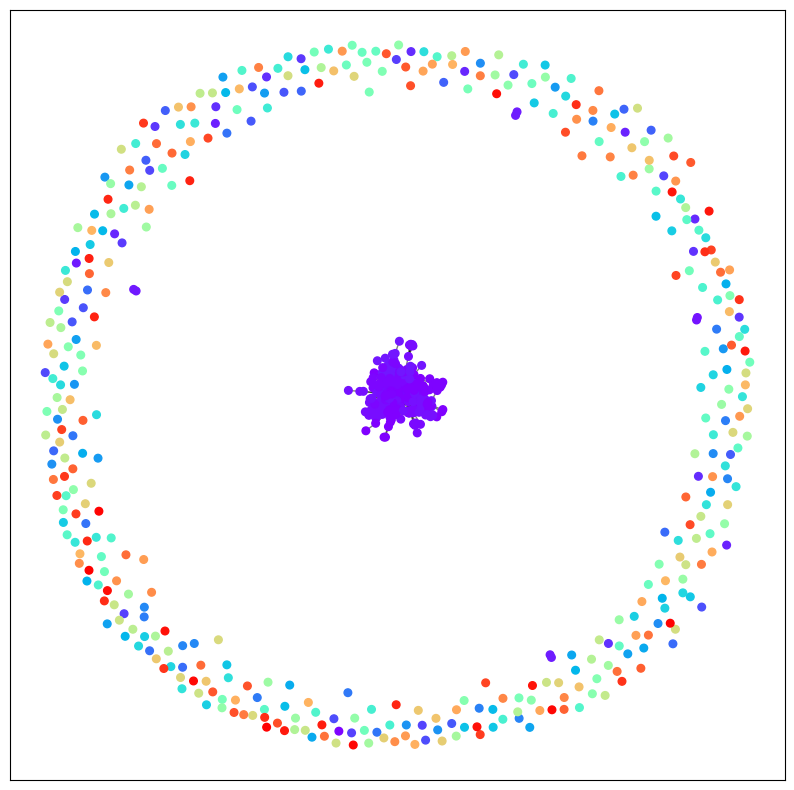

In [44]:
pos = nx.spring_layout(G_col_fil)
plt.figure(figsize=(10, 10))
nx.draw_networkx_nodes(G_col_fil, pos, node_size=30, cmap=plt.cm.rainbow, node_color=list(partition.values()))
nx.draw_networkx_edges(G_col_fil, pos, alpha=0.5)
plt.show()

In [45]:
graphs = [G_col_fil, G_agri_fil, G_energy_fil, G_enterprise_fil, G_environmental_fil, G_fish_fil, G_industrial_fil, G_info_fil, G_research_fil, G_transport_fil]
for graph in graphs:
    degree_centrality = nx.degree_centrality(graph)
    most_influential_degree = sorted(degree_centrality.items(), key=lambda x: x[1], reverse=True)
    print("\nMost influential by degree centrality:")
    print(most_influential_degree[:5])


Most influential by degree centrality:
[('VONDRA Alexandr (ECR)', 0.057180851063829786), ('RUISSEN Bert-Jan (ECR)', 0.045212765957446804), ('EICKHOUT Bas (Greens/EFA)', 0.043882978723404256), ('CUFFE Ciarán (Greens/EFA)', 0.043882978723404256), ('CANFIN Pascal (Renew)', 0.03856382978723404)]

Most influential by degree centrality:
[('DAVID Ivan (ID)', 0.0625), ('HAZEKAMP Anja (The Left)', 0.057291666666666664), ('KATAINEN Elsi (Renew)', 0.05208333333333333), ('ZALEWSKA Anna (ECR)', 0.05208333333333333), ('RUISSEN Bert-Jan (ECR)', 0.05208333333333333)]

Most influential by degree centrality:
[('BORCHIA Paolo (ID)', 0.0945945945945946), ('BLOSS Michael (Greens/EFA)', 0.07432432432432433), ('MESURE Marina (The Left)', 0.07432432432432433), ('KRASNODĘBSKI Zdzisław (ECR)', 0.07432432432432433), ('PETERSEN Morten (Renew)', 0.060810810810810814)]

Most influential by degree centrality:
[('GRUFFAT Claude (Greens/EFA)', 0.07272727272727272), ('VAIDERE Inese (EPP)', 0.05454545454545454), ('AUBR

## Louvain Community detection

In [72]:
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches

def plot_graph_by_attribute(G, attribute, layout='spring', cmap=plt.cm.get_cmap('tab20')):
    """
    Draw a NetworkX graph with nodes colored by a given node attribute.
    
    Parameters:
    - G: NetworkX graph
    - attribute: str, the node attribute to color by
    - layout: str, which layout to use ('spring', 'kamada_kawai', 'circular', etc.)
    - cmap: matplotlib colormap to use
    """

    plt.figure(figsize=(8, 6))

    # Choose layout
    if layout == 'spring':
        pos = nx.spring_layout(G)
    elif layout == 'kamada_kawai':
        pos = nx.kamada_kawai_layout(G)
    elif layout == 'circular':
        pos = nx.circular_layout(G)
    elif layout == 'random':
        pos = nx.random_layout(G)
    elif layout == 'shell':
        pos = nx.shell_layout(G)
    elif layout == 'spectral':
        pos = nx.spectral_layout(G)
    else:
        raise ValueError(f"Unsupported layout: {layout}")
    
    # Extract attribute values
    attr_values = [G.nodes[n].get(attribute, None) for n in G.nodes()]
    
    # Get unique values and assign a color index to each
    unique_vals = sorted(set(attr_values))
    val_to_color = {val: i for i, val in enumerate(unique_vals)}
    color_indices = [val_to_color[val] for val in attr_values]
    
    # Draw the graph with smaller nodes and no labels
    nx.draw(
        G, pos, node_color=color_indices, cmap=cmap, 
        with_labels=False, node_size=100, edge_color='gray', 
        linewidths=0.5,
    )
    
    # Create a discrete legend instead of colorbar
    colors = [cmap(i / max(1, len(unique_vals) - 1)) for i in range(len(unique_vals))]
    handles = [mpatches.Patch(color=color, label=str(label)) for color, label in zip(colors, unique_vals)]
    
    plt.legend(handles=handles, title=attribute, bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.title(f"Graph colored by '{attribute}'")
    #plt.tight_layout()
    plt.show()

In [ ]:
# apply louvain method
def apply_louvain(Graph):
    partition = community_louvain.best_partition(Graph, weight='weight')
    nx.set_node_attributes(Graph, partition, 'louvain_community')
    return partition

def modularity(graph, partition):
    # The partition is a dictionary with nodes as key, and a designated partition as value
    L = graph.number_of_edges() # Define number of total edges
    communities = set(partition.values()) # Define partitions of communities
    M = 0 # Initialize modulatiry

    # Equation sum
    for c in communities:
        nodes_in_c = [node for node in graph.nodes if partition[node] == c]
        L_c = graph.subgraph(nodes_in_c).number_of_edges()  # Edges inside community
        k_c = sum(graph.degree(n) for n in nodes_in_c)  # Sum of node degrees
        
        M += (L_c / L) - (k_c / (2 * L))**2  # Modularity formula

    return M

def color_graph_by_community(G, partition):
    G_colored = G.copy()

    # Add community ID as node attribute
    for node, community_id in partition.items():
        G_colored.nodes[node]['community'] = community_id

    return G_colored

# summarize the sizes of the Louvain-detected communities
# index is the Louvain community ID, and the size is the number of nodes in each community
def summarize_communities(partition):
    counts = Counter(partition.values())
    return pd.DataFrame.from_dict(counts, orient='index', columns=['Size']).sort_values(by='Size', ascending=False)

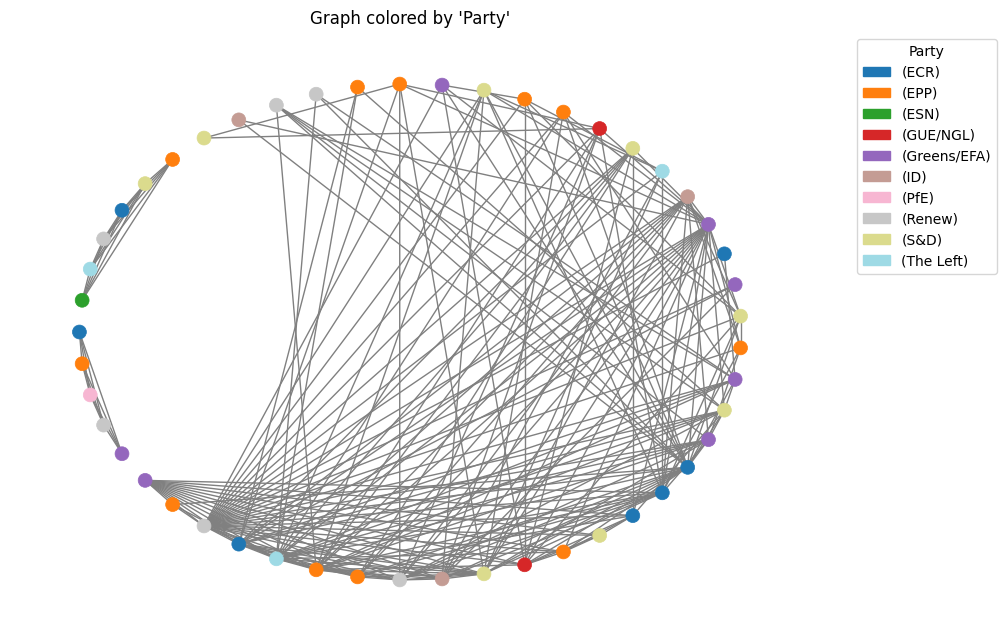

In [159]:
part = apply_louvain(filtered_network_dict["fish"])

colored = color_graph_by_community(filtered_network_dict["fish"], part)

plot_graph_by_attribute(colored, attribute='Party', layout='shell')


In [143]:
for node, data in colored.nodes(data=True):
    print(f"Node: {node}, Attributes: {data}")

Node: MILAZZO Giuseppe (ECR), Attributes: {'louvain_community': 0, 'community': 0}
Node: DO NASCIMENTO CABRAL Paulo (EPP), Attributes: {'louvain_community': 0, 'community': 0}
Node: TÂNGER CORRÊA António (PfE), Attributes: {'louvain_community': 0, 'community': 0}
Node: AGIRREGOITIA MARTÍNEZ Oihane (Renew), Attributes: {'louvain_community': 0, 'community': 0}
Node: CAMARA Mélissa (Greens/EFA), Attributes: {'louvain_community': 0, 'community': 0}
Node: GUERREIRO Francisco (Greens/EFA), Attributes: {'louvain_community': 1, 'community': 1}
Node: MILLÁN MON Francisco José (EPP), Attributes: {'louvain_community': 1, 'community': 1}
Node: BILBAO BARANDICA Izaskun (Renew), Attributes: {'louvain_community': 2, 'community': 2}
Node: ILČIĆ Ladislav (ECR), Attributes: {'louvain_community': 1, 'community': 1}
Node: PIMENTA LOPES João (The Left), Attributes: {'louvain_community': 1, 'community': 1}
Node: MONTEIRO DE AGUIAR Cláudia (EPP), Attributes: {'louvain_community': 1, 'community': 1}
Node: MAT

In [28]:
# plotting function
def plot_louvain(Graph, topic):
    partition = nx.get_node_attributes(Graph, 'louvain_community')
    pos = nx.spring_layout(Graph, k=0.15, seed=42)
    cmap = cm.get_cmap('tab20')

    plt.figure(figsize=(6, 6))
    for community_id in set(partition.values()):
        node_list = [node for node in partition if partition[node] == community_id]
        nx.draw_networkx_nodes(Graph, pos, 
                               node_size=50, 
                               nodelist=node_list, 
                               node_color=[cmap(community_id % cmap.N)])
    
    nx.draw_networkx_edges(Graph, pos, alpha=0.3)
    plt.title(f"Louvain Communities in {topic} Network")
    plt.axis('off')
    plt.show()

In [77]:
# run Louvain on all graphs
def run_louvain_all(graphs_by_topic):
    partitions = {}
    summaries = {}

    for topic, graph in graphs_by_topic.items():
        print(f"Processing: {topic}")
        partition = apply_louvain(graph)
        summary_df = summarize_communities(partition)
        
        partitions[topic] = partition
        summaries[topic] = summary_df

        plot_louvain(graph, topic)
        print(summary_df, "\n")

    return partitions, summaries

Processing: collected


/var/folders/c_/q2yk81hd0zj7jnx_b5275pzh0000gn/T/ipykernel_52427/199204488.py:5: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('tab20')


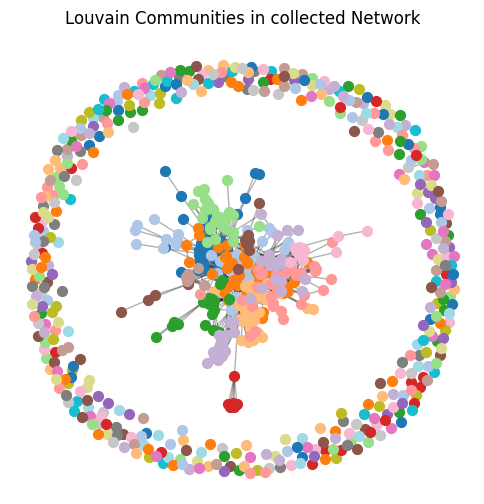

     Size
1      53
0      42
2      41
3      34
7      33
..    ...
153     1
152     1
151     1
150     1
8       1

[438 rows x 1 columns] 

Processing: agriculture


/var/folders/c_/q2yk81hd0zj7jnx_b5275pzh0000gn/T/ipykernel_52427/199204488.py:5: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('tab20')


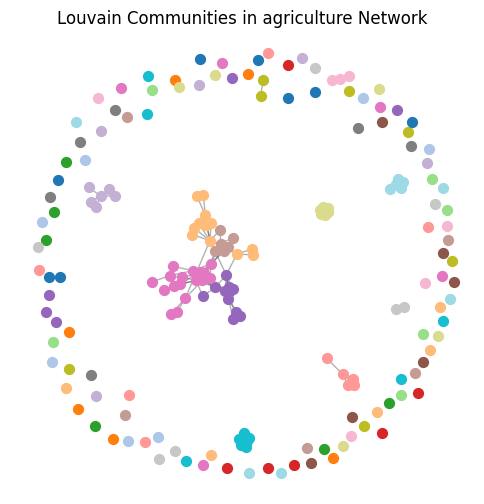

    Size
12    18
3     12
8     11
18     7
17     6
..   ...
52     1
51     1
50     1
49     1
1      1

[122 rows x 1 columns] 

Processing: energy


/var/folders/c_/q2yk81hd0zj7jnx_b5275pzh0000gn/T/ipykernel_52427/199204488.py:5: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('tab20')


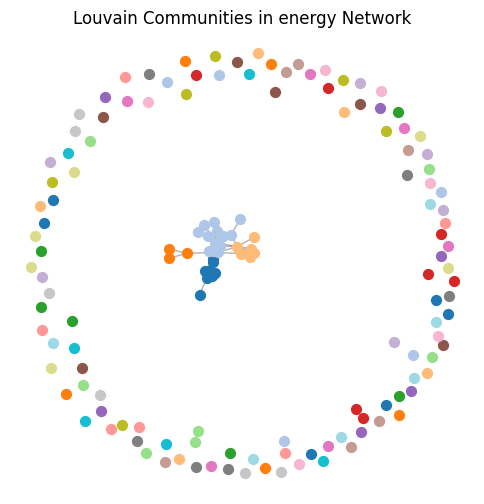

    Size
1     13
0      8
3      6
2      3
5      2
..   ...
39     1
38     1
37     1
36     1
4      1

[121 rows x 1 columns] 

Processing: enterprise


/var/folders/c_/q2yk81hd0zj7jnx_b5275pzh0000gn/T/ipykernel_52427/199204488.py:5: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('tab20')


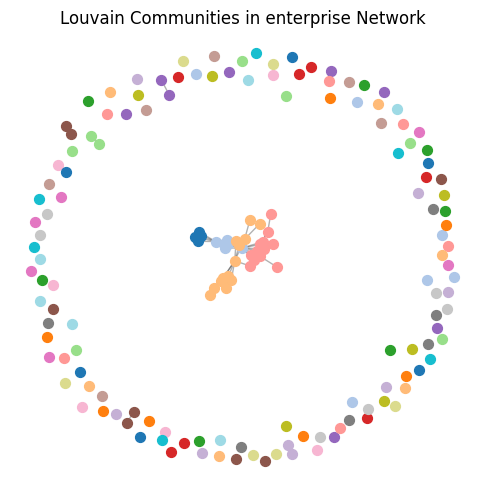

    Size
3     13
7     12
1      6
0      4
5      2
..   ...
45     1
44     1
43     1
42     1
6      1

[131 rows x 1 columns] 

Processing: environmental


/var/folders/c_/q2yk81hd0zj7jnx_b5275pzh0000gn/T/ipykernel_52427/199204488.py:5: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('tab20')


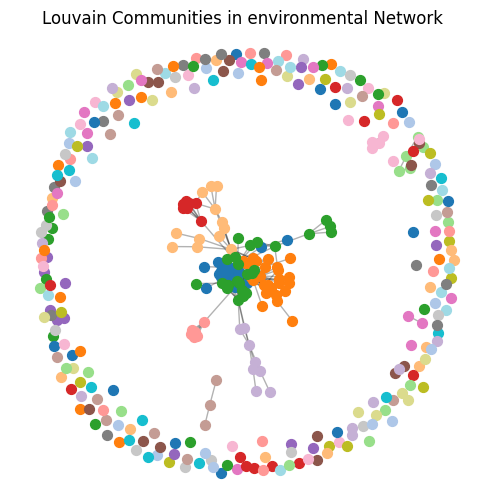

     Size
2      27
4      24
0      15
3      12
9       8
..    ...
101     1
102     1
103     1
104     1
1       1

[265 rows x 1 columns] 

Processing: fisheries


/var/folders/c_/q2yk81hd0zj7jnx_b5275pzh0000gn/T/ipykernel_52427/199204488.py:5: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('tab20')


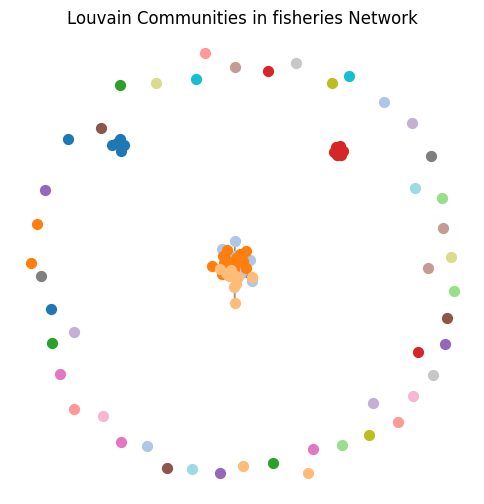

    Size
2     14
1     13
3     11
6      6
0      5
42     1
33     1
34     1
35     1
36     1
37     1
38     1
39     1
40     1
41     1
44     1
43     1
31     1
45     1
46     1
47     1
48     1
49     1
50     1
51     1
52     1
4      1
32     1
28     1
30     1
29     1
7      1
8      1
9      1
10     1
11     1
12     1
13     1
14     1
15     1
16     1
17     1
18     1
19     1
20     1
21     1
22     1
23     1
24     1
25     1
26     1
27     1
5      1 

Processing: industrial


/var/folders/c_/q2yk81hd0zj7jnx_b5275pzh0000gn/T/ipykernel_52427/199204488.py:5: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('tab20')


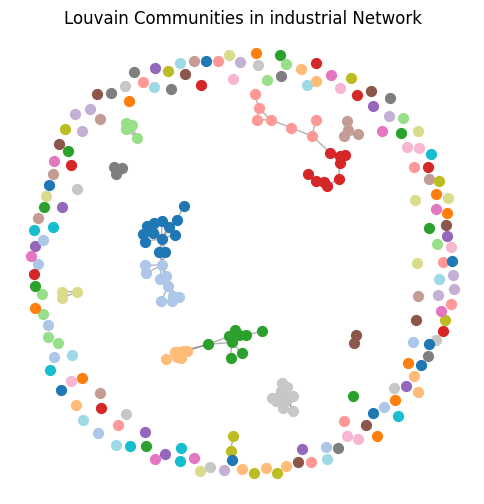

    Size
0     13
15    11
1     10
4      9
6      9
..   ...
70     1
71     1
72     1
73     1
13     1

[171 rows x 1 columns] 

Processing: information


/var/folders/c_/q2yk81hd0zj7jnx_b5275pzh0000gn/T/ipykernel_52427/199204488.py:5: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('tab20')


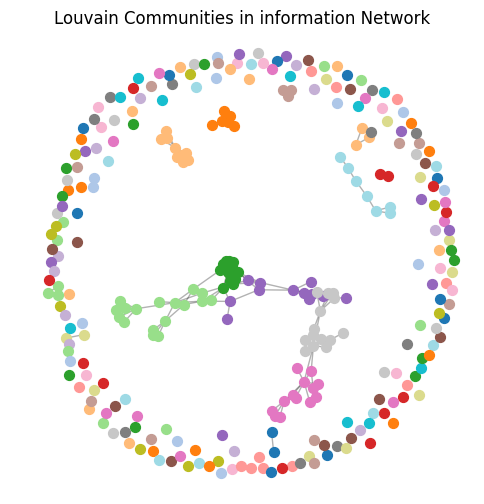

    Size
5     17
4     15
15    14
12    13
8     12
..   ...
94     1
95     1
96     1
97     1
0      1

[213 rows x 1 columns] 

Processing: research


/var/folders/c_/q2yk81hd0zj7jnx_b5275pzh0000gn/T/ipykernel_52427/199204488.py:5: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('tab20')


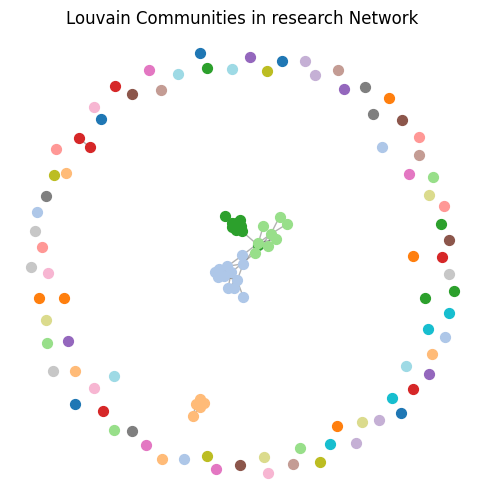

    Size
1     12
4      9
5      8
3      5
6      2
..   ...
31     1
30     1
29     1
28     1
0      1

[87 rows x 1 columns] 

Processing: transport


/var/folders/c_/q2yk81hd0zj7jnx_b5275pzh0000gn/T/ipykernel_52427/199204488.py:5: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('tab20')


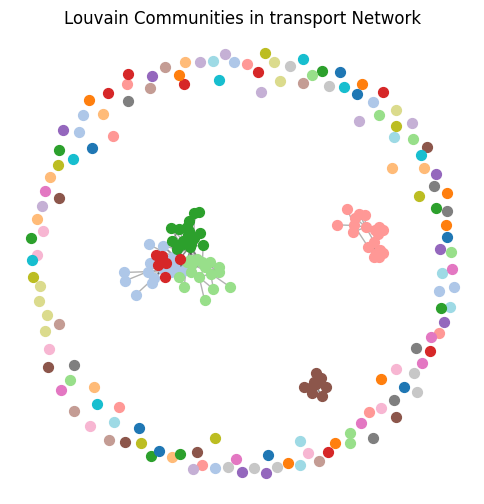

    Size
7     19
4     18
5     17
1     16
10     9
..   ...
57     1
58     1
59     1
60     1
9      1

[148 rows x 1 columns] 



In [ ]:
# our topics
graphs_by_topic = {
    "collected": G_col_fil,
    "agriculture": G_agri_fil,
    "energy": G_energy_fil,
    "enterprise": G_enterprise_fil,
    "environmental": G_environmental_fil,
    "fisheries": G_fish_fil,
    "industrial": G_industrial_fil,
    "information": G_info_fil,
    "research": G_research_fil,
    "transport": G_transport_fil
}

partitions_by_topic, summaries_by_topic = run_louvain_all(graphs_by_topic)

# Text Analysis

In [ ]:
def extract_summary(link, retries=3, delay=2, headers=None, max_timeout=None):
    r = fetch_with_retry(link, retries, delay, headers, max_timeout) # Requests Procedure URL
    soup = BeautifulSoup(r.content)

    


Procedure: https://oeil.secure.europarl.europa.eu/oeil/sl/procedure-file?reference=2020/2115(INI)
Procedure Status: Procedure completed
{'Committee report tabled for plenary': 'https://oeil.secure.europarl.europa.eu/oeil/en/document-summary?id=1644436', 'Decision by Parliament': 'https://oeil.secure.europarl.europa.eu/oeil/en/document-summary?id=1647907', 'A9-0269/2020': 'https://oeil.secure.europarl.europa.eu/oeil/en/document-summary?id=1644436', 'T9-0016/2021': 'https://oeil.secure.europarl.europa.eu/oeil/en/document-summary?id=1647907'}


{'Committee report tabled for plenary': 'https://oeil.secure.europarl.europa.eu/oeil/en/document-summary?id=1644436',
 'Decision by Parliament': 'https://oeil.secure.europarl.europa.eu/oeil/en/document-summary?id=1647907',
 'A9-0269/2020': 'https://oeil.secure.europarl.europa.eu/oeil/en/document-summary?id=1644436',
 'T9-0016/2021': 'https://oeil.secure.europarl.europa.eu/oeil/en/document-summary?id=1647907'}

In [ ]:
nanlist = get_nan(df_dict["collected"], "summary_link", "document_id")

print(len(nanlist))

for nanid in nanlist:
    get_summary_link(nanid)

In [106]:
df_topic[df_topic["summary_link"].isna()]

,document_id,title,rapporteurs,shadow_rapporteurs,summary_link,topic
13,2023/0062(COD),Specific rules relating to the entry into Nort...,"CANFIN Pascal (Renew), HLAVÁČEK Martin (Renew)","MARKEY Colm (EPP), CLUNE Deirdre (EPP), DE CAS...",NaN,agri
15,2022/0390(COD),Labelling of organic pet food,HÄUSLING Martin (Greens/EFA),"SCHMIEDTBAUER Simone (EPP), BIELOWSKI Theresa ...",NaN,agri
28,2020/0054(COD),Specific measures to provide exceptional flexi...,OMARJEE Younous (GUE/NGL),NaN,NaN,agri
36,2023/0222R(NLE),EU/Côte d’Ivoire Voluntary Partnership Agreeme...,KARLSBRO Karin (Renew),"WARBORN Jörgen (EPP), KUMPULA-NATRI Miapetra (...",NaN,agri
38,2022/0142M(NLE),EU/Guyana Voluntary Partnership Agreement: for...,KARLSBRO Karin (Renew),"WARBORN Jörgen (EPP), KUMPULA-NATRI Miapetra (...",NaN,agri
...,...,...,...,...,...,...
680,2020/2115(INI),Connectivity and EU-Asia relations,BÜTIKOFER Reinhard (Greens/EFA),"DELI Andor (EPP), OLEKAS Juozas (S&D), DZHAMBA...",NaN,transport
681,2019/2205(INI),Implementation report on the road safety aspec...,LUTGEN Benoît (EPP),"UJHELYI István (S&D), GHEORGHE Vlad (Renew), M...",NaN,transport
682,2019/2193(INI),Technical and operational measures for more ef...,DELLI Karima (Greens/EFA),"ADAMOWICZ Magdalena (EPP), TAX Vera (S&D), NAG...",NaN,transport
683,2019/2192(INI),Revision of the Trans-European Transport Netwo...,GIESEKE Jens (EPP),"GARCÍA MUÑOZ Isabel (S&D), RIQUET Dominique (R...",NaN,transport


In [95]:
df_agri.iloc[0]

document_id                                              2024/0027(COD)
title                 Granting equivalence with EU requirements to M...
rapporteurs                                   VRECIONOVÁ Veronika (ECR)
shadow_rapporteurs    BUDA Daniel (EPP), CÂRCIU Gheorghe (S&D), PENN...
summary_link          https://oeil.secure.europarl.europa.eu/oeil/en...
topic                                                              agri
Name: 0, dtype: object

In [ ]:
df_topic.iloc[0]["summary_link"]

'https://oeil.secure.europarl.europa.eu/oeil/en/document-summary?id=1774496'

In [86]:
df_topic.iloc[680]

document_id                                              2020/2115(INI)
title                                Connectivity and EU-Asia relations
rapporteurs                             BÜTIKOFER Reinhard (Greens/EFA)
shadow_rapporteurs    DELI Andor (EPP), OLEKAS Juozas (S&D), DZHAMBA...
summary_link                                                        NaN
topic                                                         transport
Name: 680, dtype: object

In [87]:
df_topic["summary_link"].isna().sum()

272